In [41]:
from chipanalysis.utils.file_reader import *
from pathlib import Path
from aicspylibczi import CziFile
import matplotlib.pyplot as plt
import numpy as np
%matplotlib widget


In [42]:
root_path = "/home/bisot/shares/van_gestel_server/ZeissData/slugs"
czi_name = "slugcrossing.czi"

czi_path = Path(root_path,czi_name)
czi = CziFile(czi_path)

dims = czi.dims
sizes = czi.size

dim_sizes = dict(zip(dims, sizes))
dim_sizes["T"]


115

In [79]:
pixel_size = get_pixel_sizes_um(czi)
times = get_timestamps_by_T(czi, C=0, Z=0)

times

.//Scaling//Distance[@Id='X']//Value
.//Scaling//Distance[@Id='Y']//Value


[(0, '2025-12-22T12:20:30.8471577Z'),
 (1, '2025-12-22T12:30:29.7422923Z'),
 (2, '2025-12-22T12:40:29.7535819Z'),
 (3, '2025-12-22T12:50:29.7430474Z'),
 (4, '2025-12-22T13:00:31.1394338Z'),
 (5, '2025-12-22T13:10:29.8373608Z'),
 (6, '2025-12-22T13:20:29.7981815Z'),
 (7, '2025-12-22T13:30:29.7589920Z'),
 (8, '2025-12-22T13:40:29.7479184Z'),
 (9, '2025-12-22T13:50:29.7577629Z'),
 (10, '2025-12-22T14:00:29.8108834Z'),
 (11, '2025-12-22T14:10:31.3189119Z'),
 (12, '2025-12-22T14:20:29.7474150Z'),
 (13, '2025-12-22T14:30:29.7582094Z'),
 (14, '2025-12-22T14:40:31.2457339Z'),
 (15, '2025-12-22T14:50:29.7399171Z'),
 (16, '2025-12-22T15:00:29.7607925Z'),
 (17, '2025-12-22T15:10:29.7515792Z'),
 (18, '2025-12-22T15:20:29.7540236Z'),
 (19, '2025-12-22T15:30:29.7558218Z'),
 (20, '2025-12-22T15:40:29.7435523Z'),
 (21, '2025-12-22T15:50:29.7457507Z'),
 (22, '2025-12-22T16:00:29.7342619Z'),
 (23, '2025-12-22T16:10:29.7521267Z'),
 (24, '2025-12-22T16:20:31.3889464Z'),
 (25, '2025-12-22T16:30:31.1879288Z

In [45]:
import numpy as np

def get_frame(
    czi,
    time,
    channel,
    gamma=1.0,
    roi=None,
    scale_factor=1.0
):
    """
    Load a frame from a CZI mosaic.
    
    Parameters
    ----------
    roi : dict or None
        {"x0","y0","x1","y1"} in FULL-RES pixel coordinates
    scale_factor : float
        Same scale_factor used in read_mosaic()
    """

    mosaic = czi.read_mosaic(
        C=channel,
        T=time,
        scale_factor=scale_factor
    )

    img = _squeeze_to_2d(mosaic).astype(np.float32)

    # --- Apply ROI if provided ---
    if roi is not None:
        # Convert ROI from full-res to current scale
        x0 = int(round(roi["x0"] * scale_factor))
        x1 = int(round(roi["x1"] * scale_factor))
        y0 = int(round(roi["y0"] * scale_factor))
        y1 = int(round(roi["y1"] * scale_factor))

        # Clamp to image bounds
        h, w = img.shape
        x0, x1 = np.clip([x0, x1], 0, w)
        y0, y1 = np.clip([y0, y1], 0, h)

        img = img[y0:y1, x0:x1]

    # --- Display-only contrast ---
    img_disp = stretch_contrast(img, 1, 99)

    if gamma != 1.0:
        img_disp = np.clip(img_disp, 0, 1) ** gamma

    return img, img_disp


In [46]:
channel = 1
time = 100
img, img_disp = get_frame(czi,time,channel)

In [47]:
roi_saved = {'x0': 50.77272727272748,
 'y0': 2449.603896103896,
 'x1': 1995.4740259740256,
 'y1': 6009.396103896104}

In [48]:
channel = 2
time = 110
img, img_disp = get_frame(czi,time,channel,roi=roi_saved,gamma=1)

In [86]:
from chipanalysis.scripts.make_video import make_frame_array_from_image, CFG
from datetime import timedelta
from dataclasses import replace
import cv2
CFG_A = replace(CFG,
                add_scale_bar=True,
                box_alpha=30,
                timestamp_position="br",
                bar_position="bl",
                units_per_pixel = pixel_size['X'],
                bar_length_units =500 )

In [91]:
first_ts = times[0][1]
ts = times[time][1]
def get_datetime(isoformat_str):
    dt = datetime.fromisoformat(
        isoformat_str.replace("Z", "+00:00")[:26] + "+00:00"
    )
    return(dt)

def make_annotated(im,time,times,units_per_pixel,resize_width,mode = "RGB"):
    CFG_A = replace(CFG,
                add_scale_bar=True,
                box_alpha=30,
                timestamp_position="br",
                bar_position="bl",
                units_per_pixel = units_per_pixel,
                bar_length_units =500,
                resize_width = resize_width)
    np_img_u8 = (np.clip(im, 0, 1) * 255).astype(np.uint8)
    pil_img = Image.fromarray(np_img_u8, mode=mode)
    cfg = CFG_A
    first_ts = get_datetime(times[0][1])
    ts = get_datetime(times[time][1])

    frame = make_frame_array_from_image(pil_img, ts, first_ts, CFG_A)
    return(frame)

/tmp/ipykernel_65313/817668995.py:2: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil_img = Image.fromarray(np_img_u8, mode="L")
/tmp/ipykernel_65313/1395481496.py:19: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil_img = Image.fromarray(np_img_u8, mode=mode)


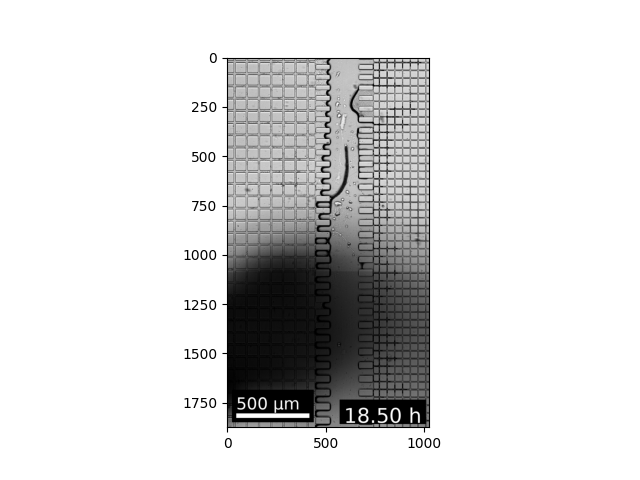

In [ ]:
frame = make_annotated(
    img_disp,
    time,
    times,
    pixel_size["X"],
    resize_width= 1024,
    mode = "L"
)
fig,ax = plt.subplots()
ax.imshow(frame,cmap="gray")

In [20]:
import numpy as np
from skimage.restoration import rolling_ball
from skimage.transform import resize
def rolling_ball_bg_subtract(img, radius):
    """
    Fiji-like rolling ball background subtraction.
    
    img: 2D numpy array
    radius: ball radius in pixels (try 30–100)
    """
    background = opening(img, disk(radius))
    corrected = img - background
    corrected[corrected < 0] = 0
    return corrected


In [ ]:
def correct_bckgd(im):
    down = 40
    small = resize(
            im,
            (im.shape[0] // down, im.shape[1] // down),
            order=1,
            anti_aliasing=True,
            preserve_range=True,
        ).astype(np.float32)
    bg_small = rolling_ball(small,radius = 250)
    bg = resize(
        bg_small,
        im.shape,
        order=1,
        anti_aliasing=False,
        preserve_range=True,
    ).astype(np.float32)
    corrected = im/bg
    corrected = stretch_contrast(corrected, 1, 99)
    return(corrected)

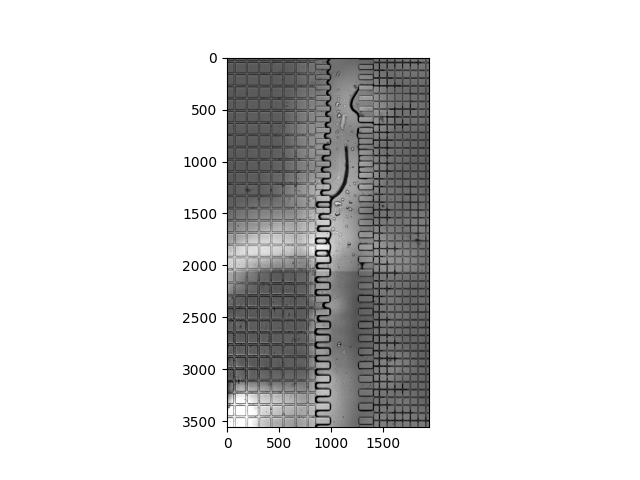

In [22]:
fig,ax = plt.subplots()
ax.imshow(correct_bckgd(img_disp),cmap="gray")

In [23]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

mcherry = LinearSegmentedColormap.from_list(
    "mcherry",
    [
        (0.00, "#000000"),  # black
        (0.25, "#2a001f"),  # very dark purple
        (0.50, "#5c005c"),  # purple
        (0.75, "#a100a1"),  # strong magenta
        (1.00, "#ff33ff"),  # bright magenta
    ]
)

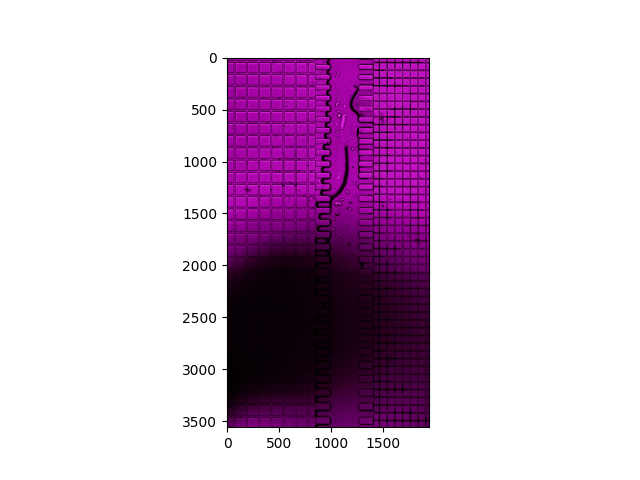

In [24]:
fig,ax = plt.subplots()
ax.imshow(img_disp,cmap=mcherry)

In [31]:
from matplotlib import cm
time = 100
channel = 1
img, ch_magenta = get_frame(czi,time,channel,roi=roi_saved)
channel = 2
img, ch_gray = get_frame(czi,time,channel,gamma=1,roi=roi_saved)
ch_gray = correct_bckgd(ch_gray)


/tmp/ipykernel_65313/2148340958.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  gray_cmap = cm.get_cmap("gray")


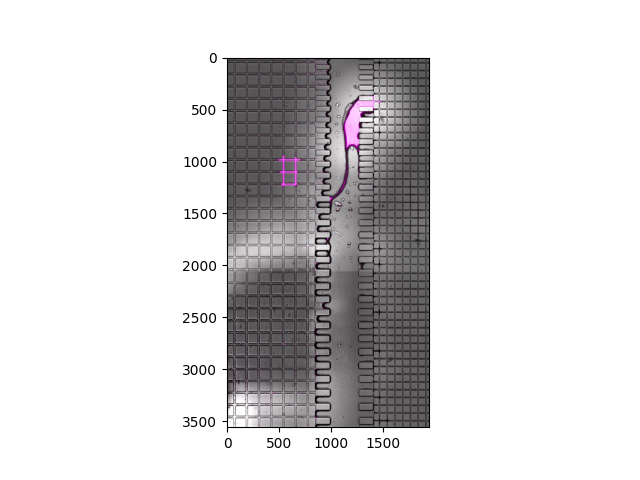

In [32]:
mcherry = LinearSegmentedColormap.from_list(
    "mcherry",
    [
        (0.00, "#000000"),  # black
        (0.33, "#2a001f"),  # very dark purple
        (0.66, "#5c005c"),  # purple
        (1, "#a100a1"),  # strong magenta
    ]
)
def norm(x):
    x = x.astype(float)
    return (x - x.min()) / (x.max() - x.min() + 1e-8)

ch_magenta = norm(ch_magenta)
ch_gray = norm(ch_gray)

# Colormaps
magenta_cmap = mcherry # or ij_magenta
gray_cmap = cm.get_cmap("gray")

# Map to RGB
rgb_magenta = magenta_cmap(ch_magenta)[..., :3]
rgb_gray = gray_cmap(ch_gray)[..., :3]

# Merge (additive, like fluorescence)
merged = np.clip(rgb_magenta + rgb_gray, 0, 1)

fig,ax = plt.subplots()
ax.imshow(merged)